<a href="https://colab.research.google.com/github/chetan-3028/ML/blob/main/chebyshev_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


iris = load_iris()

#only 2 features so we can visualize easily

X = iris.data[:, :2]
y = iris.target

# We use only 2 classes: Setosa (0) vs Versicolor (1)
mask = y < 2
X = X[mask]
y = y[mask]

class_names = ["Setosa", "Versicolor"]
class_colors = ["#1f9fd4", "#f97316"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"  Training samples : {len(X_train)}")
print(f"  Testing  samples : {len(X_test)}")
print(f"  Features used    : Sepal Length, Sepal Width")


  Training samples : 80
  Testing  samples : 20
  Features used    : Sepal Length, Sepal Width


In [9]:
class ChebyshevClassifier:
  def __init__(self,lambda_val =2.0):
    self.lambda_val = lambda_val
    self.class_stats = {}

  def fit(self,X,y):
    self.classes_ = np.unique(y)
    for c in self.classes_:
      x_c = X[y==c]
      mu = np.mean(x_c,axis=0)
      std = np.std(x_c,axis=0)
      self.class_stats[c] = {"mu":mu,"std":std}

  def chebyshev_distance(self, x, c):

    mu = self.class_stats[c]["mu"]
    std = self.class_stats[c]["std"]
    x_norm = (x - mu) / std
    return max(np.abs(x_norm))

  def predict_single(self, x):
    distances = {c: self.chebyshev_distance(x, c) for c in self.classes_}
    return min(distances, key=distances.get), distances
  def predict(self, X):

    return np.array([self.predict_single(x)[0] for x in X])



In [10]:
clf = ChebyshevClassifier(lambda_val=2.0)
clf.fit(X_train, y_train)

In [14]:
my_point = np.array([5.5, 3.0])
predicted_class, distances = clf.predict_single(my_point)

print(f"Predicted class: {class_names[predicted_class]}")
if(distances[predicted_class]<clf.lambda_val):
  print("in the region")
  print(distances[predicted_class])
  print(clf.lambda_val)
  print(distances)
else:
  print("not in the region outof bound!")

Predicted class: Versicolor
in the region
0.8237916150858012
2.0
{np.int64(0): np.float64(1.4975497667455997), np.int64(1): np.float64(0.8237916150858012)}


In [16]:
y_pred = clf.predict(X_test)
TP = np.sum((y_pred == 1) & (y_test == 1))
TN = np.sum((y_pred == 0) & (y_test == 0))
FP = np.sum((y_pred == 1) & (y_test == 0))
FN = np.sum((y_pred == 0) & (y_test == 1))
gp = TP+FN
gn = TN+FP
dp = TP + FP
dn = TN + FN
TPR = TP / (TP + FN) if (TP + FN) > 0 else 0   # Recall / Sensitivity
TNR = TN / (TN + FP) if (TN + FP) > 0 else 0   # Specificity
PPV = TP / (TP + FP) if (TP + FP) > 0 else 0   # Precision
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0   # False Alarm Rate
F1  = 2 * PPV * TPR / (PPV + TPR) if (PPV + TPR) > 0 else 0
ACC = (TP + TN) / (TP + TN + FP + FN)



In [17]:
print("  PERFORMANCE ON TEST SET  (λ = 2.0)")

print(f"\n  Confusion Matrix:")
print(f"               Predicted")
print(f"              Set   Ver")
print(f"  Actual Set [  {TN:2d}    {FP:2d} ]  ← TN / FP")
print(f"  Actual Ver [  {FN:2d}    {TP:2d} ]  ← FN / TP")
print(f"\n  Performance Measures:")
print(f"    Accuracy         (ACC): {ACC:.4f}  ({ACC*100:.1f}%)")
print(f"    TPR / Recall     (TPR): {TPR:.4f}  (Versicolor caught)")
print(f"    Specificity      (TNR): {TNR:.4f}  (Setosa correctly rejected)")
print(f"    Precision        (PPV): {PPV:.4f}  (of Versicolor detections, correct)")
print(f"    False Alarm Rate (FPR): {FPR:.4f}")
print(f"    F1 Score              : {F1:.4f}")

  PERFORMANCE ON TEST SET  (λ = 2.0)

  Confusion Matrix:
               Predicted
              Set   Ver
  Actual Set [  12     0 ]  ← TN / FP
  Actual Ver [   0     8 ]  ← FN / TP

  Performance Measures:
    Accuracy         (ACC): 1.0000  (100.0%)
    TPR / Recall     (TPR): 1.0000  (Versicolor caught)
    Specificity      (TNR): 1.0000  (Setosa correctly rejected)
    Precision        (PPV): 1.0000  (of Versicolor detections, correct)
    False Alarm Rate (FPR): 0.0000
    F1 Score              : 1.0000


In [19]:
print("  ROC ANALYSIS — Varying λ")
print("  " + "=" * 51)
print(f"\n  {'λ':>5}  {'TPR':>6}  {'FPR':>6}  {'ACC':>6}")
print("  " + "-" * 30)
lambda_values = np.arange(0.1, 5.1, 0.1)
tpr_list, fpr_list = [], []

for lam in lambda_values:
    clf_temp = ChebyshevClassifier(lambda_val=lam)
    clf_temp.fit(X_train, y_train)
    y_p = clf_temp.predict(X_test)

    tp = np.sum((y_p == 1) & (y_test == 1))
    tn = np.sum((y_p == 0) & (y_test == 0))
    fp = np.sum((y_p == 1) & (y_test == 0))
    fn = np.sum((y_p == 0) & (y_test == 1))

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    acc = (tp + tn) / (tp + tn + fp + fn)

    tpr_list.append(tpr)
    fpr_list.append(fpr)

    if round(lam, 1) in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
        print(f"  {lam:>5.1f}  {tpr:>6.3f}  {fpr:>6.3f}  {acc:>6.3f}")

  ROC ANALYSIS — Varying λ

      λ     TPR     FPR     ACC
  ------------------------------
    0.5   1.000   0.000   1.000
    1.0   1.000   0.000   1.000
    1.5   1.000   0.000   1.000
    2.0   1.000   0.000   1.000
    2.5   1.000   0.000   1.000
    3.0   1.000   0.000   1.000
    3.5   1.000   0.000   1.000
    4.0   1.000   0.000   1.000



  Plot saved as: chebyshev_result.png


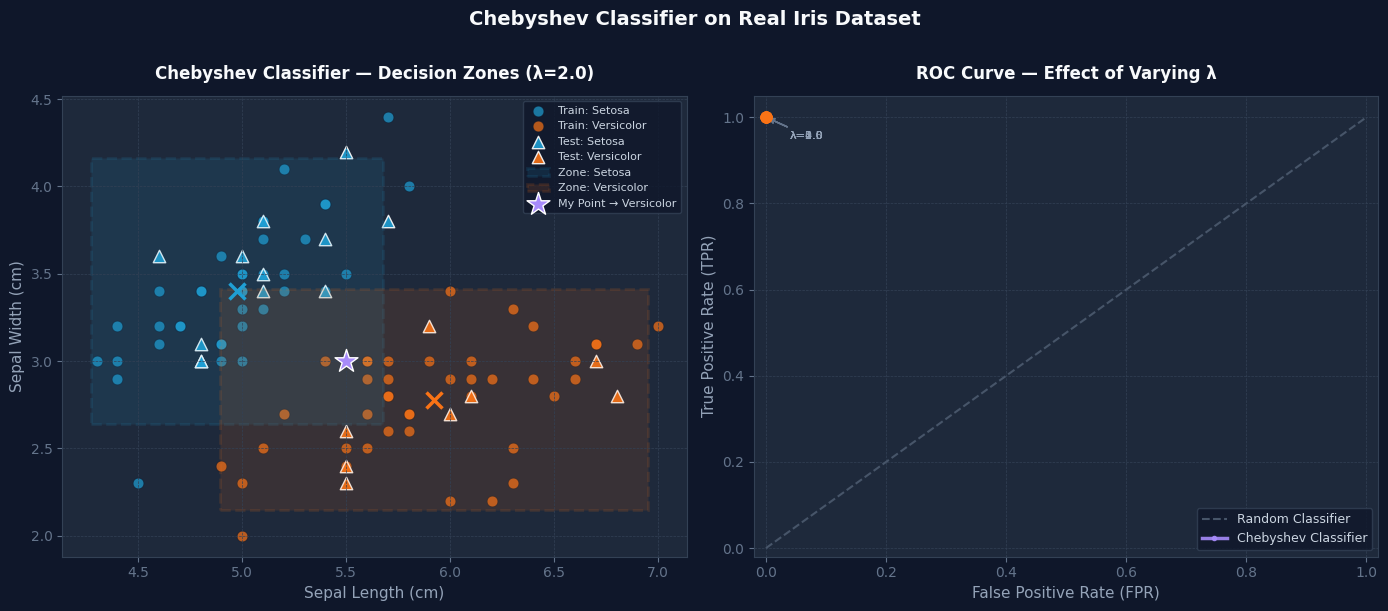

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("#0f172a")

# ── Plot 1: Scatter Plot + Decision Zones ─────────────────────
ax1 = axes[0]
ax1.set_facecolor("#1e293b")
ax1.grid(color="#334155", linewidth=0.5, linestyle="--")

for c, name, color in zip([0, 1], class_names, class_colors):
    idx = y_train == c
    ax1.scatter(X_train[idx, 0], X_train[idx, 1],
                c=color, label=f"Train: {name}",
                alpha=0.7, s=60, edgecolors="#0f172a", linewidths=0.5)

for c, name, color in zip([0, 1], class_names, class_colors):
    idx = y_test == c
    ax1.scatter(X_test[idx, 0], X_test[idx, 1],
                c=color, marker="^", alpha=0.9, s=80,
                edgecolors="white", linewidths=1.0,
                label=f"Test: {name}")

# Draw decision zones for both classes at λ=2.0
for c, zcolor in zip([0, 1], ["#1f9fd4", "#f97316"]):
    s   = clf.class_stats[c]
    lam = clf.lambda_val
    x1  = s["mu"][0] - lam * s["std"][0]
    x2  = s["mu"][0] + lam * s["std"][0]
    y1  = s["mu"][1] - lam * s["std"][1]
    y2  = s["mu"][1] + lam * s["std"][1]
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor=zcolor, facecolor=zcolor,
        alpha=0.12, linestyle="--", label=f"Zone: {class_names[c]}")
    ax1.add_patch(rect)
    ax1.plot(s["mu"][0], s["mu"][1], "x", color=zcolor,
             markersize=12, markeredgewidth=2.5)

# Mark the custom test point
ax1.scatter(my_point[0], my_point[1], c="#a78bfa", marker="*",
            s=300, zorder=5, edgecolors="white", linewidths=1,
            label=f"My Point → {class_names[predicted_class]}")

ax1.set_xlabel("Sepal Length (cm)", color="#94a3b8", fontsize=11)
ax1.set_ylabel("Sepal Width (cm)",  color="#94a3b8", fontsize=11)
ax1.set_title("Chebyshev Classifier — Decision Zones (λ=2.0)",
              color="#f8fafc", fontsize=12, fontweight="bold", pad=12)
ax1.tick_params(colors="#64748b")
for spine in ax1.spines.values():
    spine.set_edgecolor("#334155")
ax1.legend(fontsize=8, loc="upper right",
           facecolor="#0f172a", edgecolor="#334155", labelcolor="#cbd5e1")

# ── Plot 2: ROC Curve ─────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#1e293b")
ax2.grid(color="#334155", linewidth=0.5, linestyle="--")

ax2.plot([0, 1], [0, 1], "--", color="#475569",
         linewidth=1.5, label="Random Classifier")
ax2.plot(fpr_list, tpr_list, "-o", color="#a78bfa",
         linewidth=2.5, markersize=3,
         label="Chebyshev Classifier", alpha=0.9)

for lam in [0.5, 1.0, 2.0, 3.0, 4.0]:
    idx = np.argmin(np.abs(lambda_values - lam))
    ax2.annotate(f"λ={lam}",
                 xy=(fpr_list[idx], tpr_list[idx]),
                 xytext=(fpr_list[idx] + 0.04, tpr_list[idx] - 0.05),
                 color="#94a3b8", fontsize=8,
                 arrowprops=dict(arrowstyle="->", color="#64748b", lw=1))
    ax2.scatter(fpr_list[idx], tpr_list[idx],
                c="#f97316", s=60, zorder=5)

ax2.set_xlabel("False Positive Rate (FPR)", color="#94a3b8", fontsize=11)
ax2.set_ylabel("True Positive Rate (TPR)",  color="#94a3b8", fontsize=11)
ax2.set_title("ROC Curve — Effect of Varying λ",
              color="#f8fafc", fontsize=12, fontweight="bold", pad=12)
ax2.set_xlim(-0.02, 1.02)
ax2.set_ylim(-0.02, 1.05)
ax2.tick_params(colors="#64748b")
for spine in ax2.spines.values():
    spine.set_edgecolor("#334155")
ax2.legend(fontsize=9, facecolor="#0f172a",
           edgecolor="#334155", labelcolor="#cbd5e1")

plt.suptitle("Chebyshev Classifier on Real Iris Dataset",
             color="#f8fafc", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("chebyshev_result.png", dpi=150,
            bbox_inches="tight", facecolor="#0f172a")
print("\n  Plot saved as: chebyshev_result.png")
plt.show()


